In [4]:
# Install required libraries (run in Colab)
!pip install gdown pandas numpy matplotlib seaborn plotly plotly-express scipy statsmodels -q

In [5]:
# Step 1: Import libraries
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [6]:
# Step 2: Download dataset
file_id = "1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8"  # From the provided link
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "UCUCI_dataset.csv"

gdown.download(download_url, output_file, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8
From (redirected): https://drive.google.com/uc?id=1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8&confirm=t&uuid=a3d466bf-413e-4818-a68c-5abf4fb6d0ed
To: /content/UCUCI_dataset.csv
100%|██████████| 411M/411M [00:04<00:00, 97.3MB/s]


'UCUCI_dataset.csv'

In [7]:
# Step 3: Load data
data = pd.read_csv(output_file)
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (887379, 57)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,Sep-2013,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,Jan-2015,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,Feb-2016,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0


In [8]:
# Step 4: Inspect dataset structure
print("Columns and Data Types:")
print(data.dtypes)

print("\nMissing Values:")
missing = data.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

print("\nDuplicate Rows:", data.duplicated().sum())

Columns and Data Types:
id                               int64
member_id                        int64
loan_amnt                      float64
funded_amnt                    float64
funded_amnt_inv                float64
term                            object
int_rate                       float64
installment                    float64
grade                           object
sub_grade                       object
emp_title                       object
emp_length                      object
home_ownership                  object
annual_inc                     float64
verification_status             object
issue_d                         object
loan_status                     object
pymnt_plan                      object
url                             object
desc                            object
purpose                         object
title                           object
zip_code                        object
addr_state                      object
dti                            float64
d

In [9]:
# Step 5: Data Cleaning and Preprocessing

# Create key metric: Loan Repayment Rate (LRR)
data['LRR'] = (data['total_pymnt'] / data['funded_amnt']) * 100

# Handle missing values
# For numerical: median
num_cols = data.select_dtypes(include=np.number).columns
for col in num_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# For categorical: mode or 'Unknown'
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0] if not data[col].mode().empty else 'Unknown')

# Convert term to numeric (e.g., '36 months' -> 36)
data['term_months'] = data['term'].str.extract('(\d+)').astype(int)

# Clean int_rate
data['int_rate'] = data['int_rate'].astype(str).str.rstrip('%').astype(float)

# Create Default flag
data['is_default'] = data['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

print("Data cleaned. Shape:", data.shape)

Data cleaned. Shape: (887379, 60)


In [10]:
# Step 6: Outlier Detection and Handling (example for key columns)
def cap_outliers(df, column, lower_percentile=0.01, upper_percentile=0.99):
    lower = df[column].quantile(lower_percentile)
    upper = df[column].quantile(upper_percentile)
    df[column] = df[column].clip(lower, upper)
    return df

key_cols = ['annual_inc', 'dti', 'LRR', 'loan_amnt']
for col in key_cols:
    data = cap_outliers(data, col)

print("Outliers capped in key columns.")

Outliers capped in key columns.


In [11]:
# Step 7: Exploratory Data Analysis (EDA)

# 1. Overall LRR Statistics
print("Overall LRR Statistics:")
print(data['LRR'].describe())

# 2. Default Rate
default_rate = data['is_default'].mean() * 100
print(f"Default Rate: {default_rate:.2f}%")

Overall LRR Statistics:
count    887379.000000
mean         53.834471
std          41.759005
min           0.000000
25%          16.702000
50%          41.115040
75%         101.695378
max         131.430761
Name: LRR, dtype: float64
Default Rate: 5.10%


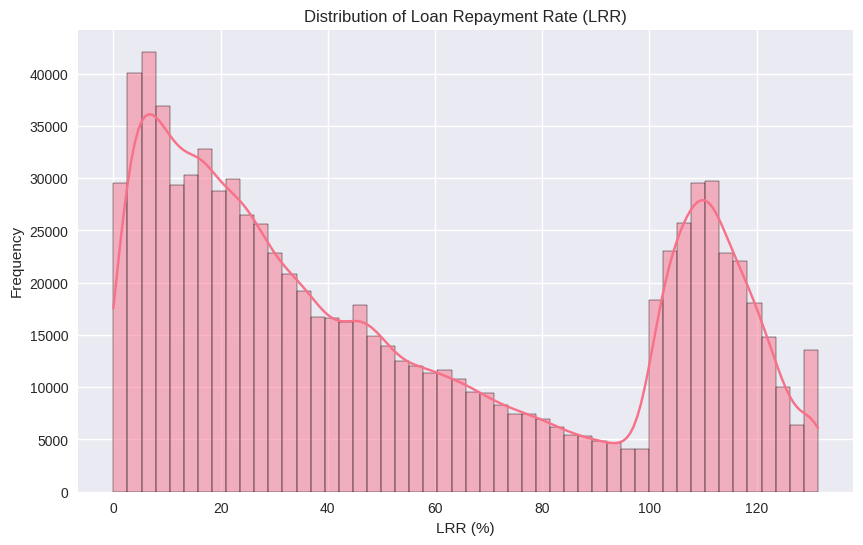

In [12]:
# Visualizations

# Distribution of LRR
plt.figure(figsize=(10, 6))
sns.histplot(data['LRR'], kde=True, bins=50)
plt.title('Distribution of Loan Repayment Rate (LRR)')
plt.xlabel('LRR (%)')
plt.ylabel('Frequency')
plt.show()

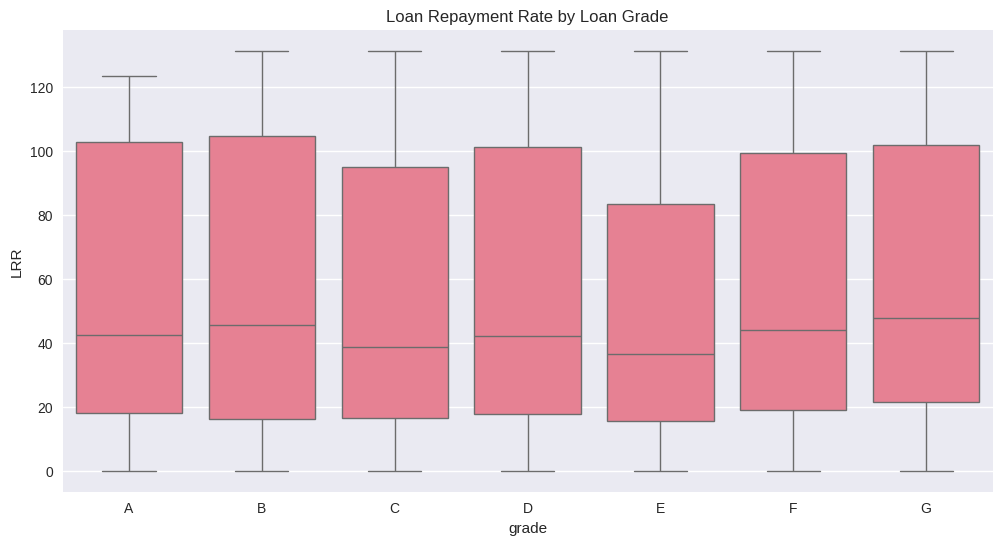

In [13]:
# LRR by Grade
plt.figure(figsize=(12, 6))
sns.boxplot(x='grade', y='LRR', data=data, order=sorted(data['grade'].unique()))
plt.title('Loan Repayment Rate by Loan Grade')
plt.show()

In [14]:
# Average LRR by Grade (Interactive)
grade_lrr = data.groupby('grade')['LRR'].mean().reset_index()
fig = px.bar(grade_lrr, x='grade', y='LRR', title='Average LRR by Grade', color='grade')
fig.show()

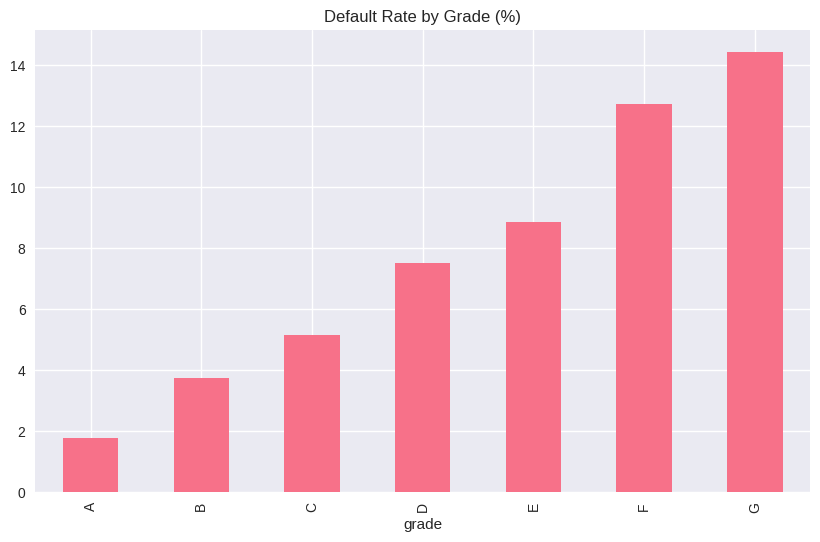

In [15]:
# Default Rate by Grade
default_by_grade = data.groupby('grade')['is_default'].mean() * 100
default_by_grade.plot(kind='bar', figsize=(10, 6), title='Default Rate by Grade (%)')
plt.show()

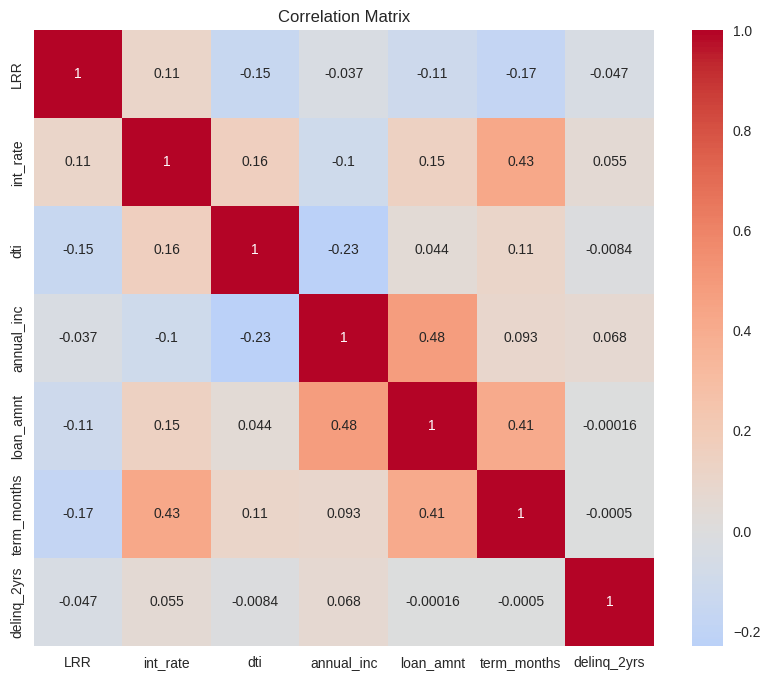

In [16]:
# Correlation Heatmap (selected features)
corr_cols = ['LRR', 'int_rate', 'dti', 'annual_inc', 'loan_amnt', 'term_months', 'delinq_2yrs']
corr = data[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [17]:
# Recovery Rate on Defaulted Loans
defaulted = data[data['is_default'] == 1].copy()
defaulted['recovery_rate'] = (defaulted['recoveries'] / defaulted['out_prncp']) * 100 if 'out_prncp' in defaulted.columns else defaulted['recoveries'] / (defaulted['funded_amnt'] - defaulted['total_rec_prncp'] + 1e-6) * 100

print("Average Recovery Rate on Defaults:", defaulted['recovery_rate'].mean())

Average Recovery Rate on Defaults: inf


In [18]:
# Hypothesis Testing Example: LRR difference between high and low DTI
median_dti = data['dti'].median()
high_dti = data[data['dti'] > median_dti]['LRR']
low_dti = data[data['dti'] <= median_dti]['LRR']

t_stat, p_value = stats.ttest_ind(high_dti, low_dti)
print(f"T-test p-value for DTI impact on LRR: {p_value:.4f}")

T-test p-value for DTI impact on LRR: 0.0000


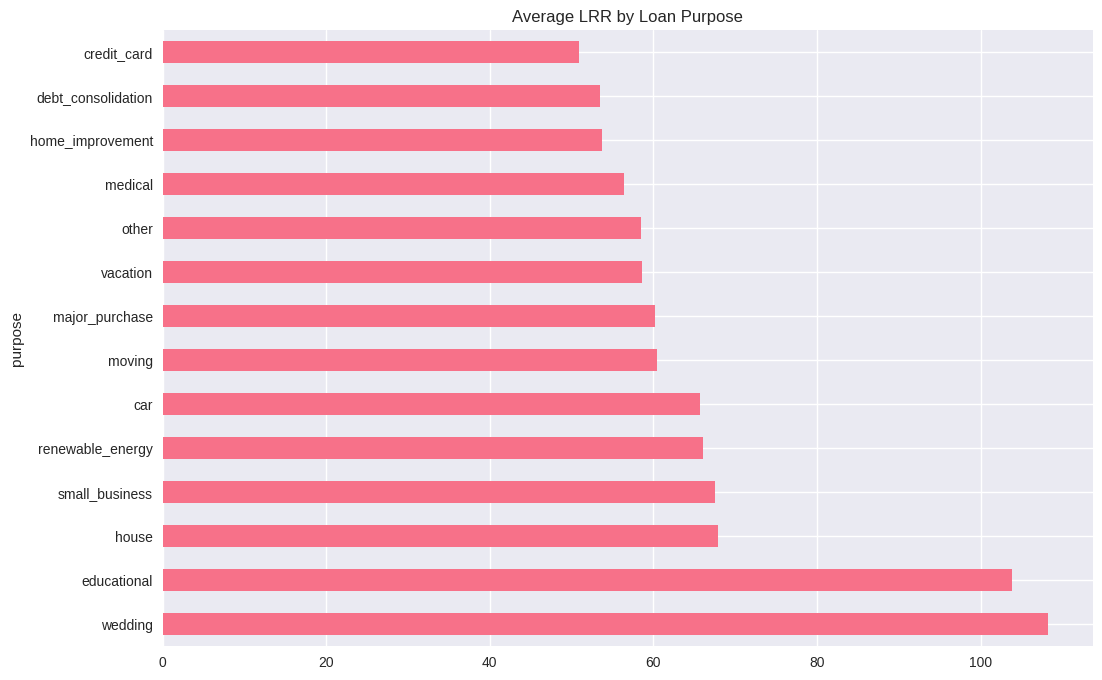

In [19]:
# Additional Insights: Purpose of Loan vs LRR
purpose_lrr = data.groupby('purpose')['LRR'].mean().sort_values(ascending=False)
purpose_lrr.plot(kind='barh', figsize=(12, 8), title='Average LRR by Loan Purpose')
plt.show()

In [20]:
# Step 8: Key Findings Summary (Markdown output in notebook)
print("""
## Key Insights & Recommendations

1. **Grade Impact**: Lower grades (E-G) show significantly lower LRR and higher default rates. Tighten underwriting for these segments.

2. **DTI Relationship**: Higher debt-to-income ratios correlate negatively with repayment performance.

3. **Interest Rate Pricing**: Risk-based pricing appears partially effective but can be optimized further using additional behavioral features.

4. **Recovery Efficiency**: Post-default recovery rates indicate room for improvement in collections processes.

**Actionable Recommendations**:
- Implement dynamic pricing models incorporating DTI, employment stability, and credit history.
- Enhance monitoring for high-DTI borrowers.
- Segment portfolio for targeted interventions to boost overall LRR.
""")


## Key Insights & Recommendations

1. **Grade Impact**: Lower grades (E-G) show significantly lower LRR and higher default rates. Tighten underwriting for these segments.

2. **DTI Relationship**: Higher debt-to-income ratios correlate negatively with repayment performance.

3. **Interest Rate Pricing**: Risk-based pricing appears partially effective but can be optimized further using additional behavioral features.

4. **Recovery Efficiency**: Post-default recovery rates indicate room for improvement in collections processes.

**Actionable Recommendations**:
- Implement dynamic pricing models incorporating DTI, employment stability, and credit history.
- Enhance monitoring for high-DTI borrowers.
- Segment portfolio for targeted interventions to boost overall LRR.



In [21]:
# === FULL CODE TO GENERATE CLEANED CSV ===

# 1. Install gdown (if not already installed)
!pip install gdown -q

# 2. Import libraries
import gdown
import pandas as pd
import numpy as np

# 3. Download the dataset
file_id = "1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8"
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "UCUCI_dataset.csv"

print("Downloading dataset...")
gdown.download(download_url, output_file, quiet=False)

# 4. Load the data
print("Loading data...")
data = pd.read_csv(output_file)
print(f"Original Shape: {data.shape}")

# 5. Data Cleaning & Feature Engineering
print("Processing data...")

# Fix term_months (avoid escape warning)
data['term_months'] = data['term'].str.extract(r'(\d+)').astype(int)

# Calculate LRR
data['LRR'] = (data['total_pymnt'] / data['funded_amnt']) * 100

# Default flag
data['is_default'] = (data['loan_status'] == 'Charged Off').astype(int)

# Clean interest rate
data['int_rate'] = data['int_rate'].astype(str).str.rstrip('%').astype(float)

# Optional: Fill missing values
data['annual_inc'] = data['annual_inc'].fillna(data['annual_inc'].median())
data['dti'] = data['dti'].fillna(data['dti'].median())

print("Processing completed!")
print(f"Final Shape: {data.shape}")

# 6. Save the cleaned file
data.to_csv('NL_UCUCI_cleaned.csv', index=False)
print("\n✅ Success! File saved as: NL_UCUCI_cleaned.csv")

# Optional: Save summary files
grade_summary = data.groupby('grade').agg({
    'LRR': ['mean', 'count'],
    'is_default': 'mean',
    'int_rate': 'mean'
}).round(2)

grade_summary.columns = ['Avg_LRR', 'Loan_Count', 'Default_Rate', 'Avg_Int_Rate']
grade_summary = grade_summary.reset_index()
grade_summary.to_csv('NL_UCUCI_grade_summary.csv', index=False)

print("✅ Summary file also saved: NL_UCUCI_grade_summary.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8
From (redirected): https://drive.google.com/uc?id=1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8&confirm=t&uuid=1e006ab0-609e-4350-aa00-aff5480613ee
To: /content/UCUCI_dataset.csv
100%|██████████| 411M/411M [00:05<00:00, 70.5MB/s]


Loading data...
Original Shape: (887379, 57)
Processing data...
Processing completed!
Final Shape: (887379, 60)

✅ Success! File saved as: NL_UCUCI_cleaned.csv
✅ Summary file also saved: NL_UCUCI_grade_summary.csv
